<a href="https://colab.research.google.com/github/nicobargioni/embeddings_lab/blob/main/Nicol%C3%A1s_Bargioni_Embeddings_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Álgebra lineal con embeddings

In [ ]:
#@title Argy Edition 🇦🇷
from IPython.display import display, HTML

display(HTML('''
<div style="font-family:Montserrat,system-ui,sans-serif;width:100%;box-sizing:border-box;
            border-radius:16px;overflow:hidden;box-shadow:0 14px 56px rgba(0,0,0,.55);
            border:1px solid rgba(79,184,232,.28);margin:6px 0">
  <div style="padding:46px 34px;text-align:center;color:#eef7fb;
       background:
         radial-gradient(120% 90% at 12% -12%, rgba(79,184,232,.36), transparent 52%),
         radial-gradient(90% 80% at 90% 120%, rgba(38,86,116,.55), transparent 60%),
         linear-gradient(160deg,#08161f 0%,#0a1b27 55%,#061019 100%)">
    <div style="font-size:2.3em;filter:drop-shadow(0 0 12px rgba(124,200,238,.7))">⚽ 🇦🇷 ✨</div>
    <h1 style="margin:.1em 0 0;font-size:2.7em;font-weight:800;letter-spacing:-.02em;text-transform:uppercase;
               line-height:1;text-shadow:0 5px 26px rgba(0,0,0,.6)">El cono bajo los
       <span style="color:#4fb8e8;text-shadow:0 0 28px rgba(79,184,232,.75)">reflectores</span></h1>
    <div style="font-size:1.0em;color:#7cc8ee;font-weight:700;letter-spacing:.2em;text-transform:uppercase;margin-top:12px">
        Álgebra lineal con embeddings · Mundial 2026</div>
  </div>
  <div style="padding:30px 34px;background:#0a141d;color:#cfe3ef;line-height:1.65;text-align:left">
    <p style="margin:0 0 14px;font-size:1.02em">
      <b style="color:#7cc8ee">🎯 De qué se trata.</b> Una computadora no entiende palabras: las convierte en
      <b>vectores</b> (listas de cientos de números). Este notebook agarra 56 frases sobre la Selección y el Mundial,
      las transforma en vectores, y usa <b>álgebra lineal</b> para mostrar cómo se organiza el significado: por qué dos
      frases se parecen, por qué todas se &laquo;apiñan&raquo; en un cono, y cómo eso afecta a un buscador o a un clustering real.</p>
    <p style="margin:0 0 14px;font-size:1.02em">
      <b style="color:#7cc8ee">👁 Qué vas a ver.</b> Un recorrido en 8 capítulos + 8 módulos de juego. Vas a ver
      <b>matrices de similitud</b> coloreadas, el <b>cono en 3D</b> que podés girar con el mouse, un
      <b>scree plot</b> que revela que de cientos de dimensiones trabajan ~45, un <b>buscador semántico</b>, un
      <b>dendrograma</b> de temas, y experimentos como analogías vectoriales, rotaciones mágicas, compresión y morphing.</p>
    <p style="margin:0;font-size:1.02em">
      <b style="color:#7cc8ee">🧭 Cómo recorrerlo.</b> Andá a <b>Entorno de ejecución → Ejecutar todo</b>. Cada sección
      arranca con una tarjeta que explica <b>qué se hace y dónde mirar</b>, después viene el gráfico, y abajo una
      <b>📝 Lectura</b> que interpreta el resultado. Cada bloque marca con 🧮 la operación de álgebra lineal que lo hace posible.</p>
  </div>
  <div style="display:flex;flex-wrap:wrap;background:#061019">
    <div style="flex:1;min-width:120px;padding:16px;text-align:center;border-right:1px solid #15303f;color:#eef7fb">
        <div style="font-size:1.8em;font-weight:800;color:#4fb8e8">56</div>
        <div style="font-size:.76em;color:#6f93a8;text-transform:uppercase;letter-spacing:.12em">frases · 7 temas</div></div>
    <div style="flex:1;min-width:120px;padding:16px;text-align:center;border-right:1px solid #15303f;color:#eef7fb">
        <div style="font-size:1.8em;font-weight:800;color:#4fb8e8">8+8</div>
        <div style="font-size:.76em;color:#6f93a8;text-transform:uppercase;letter-spacing:.12em">capítulos · módulos</div></div>
    <div style="flex:1;min-width:120px;padding:16px;text-align:center;color:#eef7fb">
        <div style="font-size:1.8em;font-weight:800;color:#4fb8e8">3D</div>
        <div style="font-size:.76em;color:#6f93a8;text-transform:uppercase;letter-spacing:.12em">interactivo</div></div>
  </div>
</div>
<style>@import url('https://fonts.googleapis.com/css2?family=Montserrat:wght@600;800&display=swap');</style>
'''))

## 0 · Preparación del entorno

In [ ]:
!pip -q install sentence-transformers >/dev/null 2>&1

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go
import plotly.express as px
from sentence_transformers import SentenceTransformer
from IPython.display import display, HTML

np.random.seed(42)


print("Descargando modelo")

# ---- paleta 'noche de estadio' ----
NIGHT="#0a1b27"; INK="#bcdcec"; BEAM="#4fb8e8"; CELESTE="#8fc0e8"; MIST="#6f93a8"; LINE="#15303f"
plt.rcParams.update({
    "figure.figsize":(9,4.5), "figure.facecolor":NIGHT, "axes.facecolor":NIGHT,
    "savefig.facecolor":NIGHT, "axes.edgecolor":LINE, "axes.labelcolor":INK,
    "text.color":INK, "axes.titlecolor":INK, "xtick.color":MIST, "ytick.color":MIST,
    "axes.grid":True, "grid.color":LINE, "grid.alpha":.5, "font.size":11, "legend.framealpha":0,
})
CINE = LinearSegmentedColormap.from_list("cine", ["#061019","#12303f","#4fb8e8","#cfe8f6"])
TCOLOR = {"jugadores":"#6cb8e8","tactica":"#8fa8e0","rivales":"#5fd0c0",
          "historia":"#e8b86a","sedes2026":"#e88a8a","hinchada":"#c9a0e8","cultura":"#aab9c8"}

def style3d(fig, title):
    ax=dict(backgroundcolor="#0a1b27", gridcolor="#13344a", showbackground=True, color="#6f93a8")
    fig.update_layout(title=title, height=560, paper_bgcolor="#0a1b27", font_color="#bcdcec",
        scene=dict(xaxis_title="eje del cono", yaxis_title="u1", zaxis_title="u2",
                   xaxis=ax, yaxis=ax, zaxis=ax))
    return fig

def intro(emoji, titulo, parrafos):
    # Tarjeta full-width estilo PP2: título + 3 párrafos (qué se hace / qué se ve / dónde mirar).
    ps = "".join(f'<p style="margin:0 0 11px;color:#cfe3ef;font-size:.97em;line-height:1.62">{p}</p>' for p in parrafos)
    return HTML(f'''
    <div style="font-family:Montserrat,system-ui,sans-serif;width:100%;box-sizing:border-box;
                background:linear-gradient(135deg,#0a1b27,#102b3c 55%,#15384b);
                border:1px solid rgba(79,184,232,.22);border-left:5px solid #4fb8e8;border-radius:12px;
                padding:22px 28px;margin:6px 0;color:#eef7fb;box-shadow:0 8px 30px rgba(0,0,0,.35)">
      <div style="font-size:1.35em;font-weight:800;text-transform:uppercase;letter-spacing:.01em;margin-bottom:13px">
          <span style="font-size:1.05em">{emoji}</span>&nbsp;{titulo}</div>
      {ps}
    </div>''')

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME)

def embed(textos):
    return model.encode(list(textos), normalize_embeddings=False, show_progress_bar=False)

print("Modelo cargado:", MODEL_NAME)

Descargando modelo


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


## 1 · El corpus

In [ ]:
display(intro("📚", "1 · El corpus: el Mundial en frases", [
 "<b>De qué se trata.</b> Todo experimento con embeddings empieza por un corpus: un conjunto de textos. Acá usamos 56 frases cortas repartidas en 7 sub-temas — jugadores de la Selección, táctica, rivales, historia (1978, 1986, Qatar 2022), sedes del Mundial 2026, la hinchada, y un grupo de cultura argentina no-futbolera (mate, asado, tango). Ese último grupo está puesto a propósito: es el &laquo;contraste&raquo; que después hace que las analogías y los ejes de concepto den resultados claros.",
 "<b>Qué vas a ver.</b> La celda arma un diccionario con los 7 temas y aplana todo en dos listas paralelas: <code>texts</code> (las 56 frases) y <code>topics</code> (a qué tema pertenece cada una). Esa etiqueta de tema NO se la damos al modelo — la guardamos sólo para nosotros, para después comprobar si la geometría logra reagrupar los temas por su cuenta.",
 "<b>Dónde mirar.</b> Abajo se imprime el conteo: 56 frases, 7 temas. Tené presente esos grupos porque van a reaparecer como colores en casi todos los gráficos que siguen.",
]))

CORPUS = {
 "jugadores": [
  "Lionel Messi lidera a la selección argentina como capitán y máximo referente.",
  "Emiliano Dibu Martínez es el arquero que ataja penales decisivos.",
  "Julián Álvarez se mueve como delantero veloz y desequilibrante.",
  "Lautaro Martínez pelea el puesto de centrodelantero titular.",
  "Rodrigo De Paul corre todo el mediocampo y recupera pelotas.",
  "Enzo Fernández organiza el juego desde el centro del campo.",
  "Alexis Mac Allister aporta gol y llegada desde la segunda línea.",
  "Cristian Cuti Romero es un defensor central duro y aguerrido.",
 ],
 "tactica": [
  "El equipo presiona alto para recuperar la pelota en campo rival.",
  "La línea de cuatro defensores se achica para dejar al rival en offside.",
  "El mediocampo controla la posesión y maneja los tiempos del partido.",
  "El entrenador plantea un repliegue para defender el resultado.",
  "Los laterales se proyectan al ataque por las bandas.",
  "El equipo busca la contra rápida apenas recupera el balón.",
  "La presión tras pérdida asfixia la salida del rival.",
  "El armado del juego empieza desde los pies del arquero.",
 ],
 "rivales": [
  "Brasil llega con Vinícius y Rodrygo como principales amenazas ofensivas.",
  "Francia, con Mbappé, es candidata a pelear el título.",
  "España apuesta a un juego de posesión y toque constante.",
  "Inglaterra tiene un plantel joven y profundo en ataque.",
  "Alemania busca recuperar protagonismo tras años irregulares.",
  "Países Bajos confía en su orden táctico y su mediocampo.",
  "Portugal depende del talento y la experiencia de sus figuras.",
  "Uruguay plantea partidos físicos y de gran intensidad.",
 ],
 "historia": [
  "Argentina ganó su primer Mundial en casa en 1978.",
  "Diego Maradona llevó a Argentina al título en México 1986.",
  "La mano de Dios y el gol del siglo marcaron el Mundial de 1986.",
  "En Qatar 2022 Argentina se consagró campeón del mundo.",
  "Messi levantó la copa tras la final contra Francia en 2022.",
  "La final de 2022 se definió por penales tras un empate tres a tres.",
  "Argentina luce tres estrellas mundiales en su camiseta.",
  "La consagración en Qatar coronó la carrera de Lionel Messi.",
 ],
 "sedes2026": [
  "El Mundial 2026 se jugará en Estados Unidos, México y Canadá.",
  "Será el primer Mundial con cuarenta y ocho selecciones participantes.",
  "La final se disputará en el MetLife Stadium de Nueva Jersey.",
  "Ciudad de México albergará partidos en el histórico estadio Azteca.",
  "Toronto y Vancouver serán las sedes canadienses del torneo.",
  "El Mundial repartirá los partidos en dieciséis ciudades anfitrionas.",
  "El calor del verano norteamericano será un factor en varias sedes.",
  "Estados Unidos concentrará la mayoría de los estadios del torneo.",
 ],
 "hinchada": [
  "La hinchada argentina copa las tribunas con bombos y banderas.",
  "El himno nacional se canta a todo pulmón antes de cada partido.",
  "La camiseta celeste y blanca es un símbolo de identidad nacional.",
  "Los hinchas inundan las calles para festejar cada victoria.",
  "La canción Muchachos se volvió el himno popular de la hinchada.",
  "Las banderas con la cara de Messi flamean en cada estadio.",
  "El aliento de la gente empuja al equipo en los momentos difíciles.",
  "Las caravanas de festejo desbordan el Obelisco tras los títulos.",
 ],
 "cultura": [
  "El mate es la infusión que acompaña las tardes de los argentinos.",
  "El asado del domingo reúne a la familia alrededor de la parrilla.",
  "El tango nació en los barrios porteños a orillas del Río de la Plata.",
  "Las empanadas son un clásico infaltable de la cocina criolla.",
  "El dulce de leche endulza postres y facturas en todo el país.",
  "La cumbia y el rock nacional suenan en cada fiesta popular.",
  "El Obelisco es el punto de encuentro en el centro de Buenos Aires.",
  "El café con medialunas marca el ritmo de la mañana porteña.",
 ],
}

texts, topics = [], []
for t, ss in CORPUS.items():
    for s in ss:
        texts.append(s); topics.append(t)
TOPICS = list(CORPUS.keys())
tid = np.array([TOPICS.index(t) for t in topics])
print(f"{len(texts)} frases · {len(TOPICS)} temas: {TOPICS}")

56 frases · 7 temas: ['jugadores', 'tactica', 'rivales', 'historia', 'sedes2026', 'hinchada', 'cultura']


## 2 · Qué es un embedding

In [ ]:
display(intro("🔢", "2 · Qué es un embedding", [
 "<b>De qué se trata.</b> Acá ocurre la transformación central de todo el notebook: pasamos cada una de las 56 frases por el modelo de IA y obtenemos su <b>embedding</b>, una lista de cientos de números que codifica su significado. Apilamos los 56 vectores uno debajo del otro y formamos la <b>matriz E</b>, de tamaño (56 × d). Cada fila es una frase; cada columna, una dimensión latente que el modelo aprendió.",
 "<b>Qué vas a ver.</b> Abajo se imprime la forma de la matriz (56 filas × cientos de columnas) y las primeras 8 coordenadas de la primera frase, sobre Messi. Vas a notar que son números chiquitos, positivos y negativos, sin ninguna etiqueta humana: nadie diseñó la columna 3 para que mida &laquo;fútbol&raquo;.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Lo importante no es cada número suelto sino la <b>dirección</b> del vector completo. De acá en adelante todo es geometría: apilar los vectores en una matriz nos deja operar con ellos de a miles a la vez, que es la gran ventaja del álgebra lineal.",
]))

E = embed(texts)
print("Matriz E:", E.shape, "  → 56 frases ×", E.shape[1], "dimensiones")
print("\nLas primeras 8 coordenadas de la frase 0 ('%s...'):" % texts[0][:40])
print(np.round(E[0][:8], 3))

Matriz E: (56, 384)   → 56 frases × 384 dimensiones

Las primeras 8 coordenadas de la frase 0 ('Lionel Messi lidera a la selección argen...'):
[-0.169 -0.005  0.286 -0.112  0.374 -0.126 -0.038 -0.172]


📝 **Lectura.** Cada una de las 56 frases quedó convertida en una fila de la matriz `E`, con cientos de columnas. Fijate que los números sueltos (`0.041`, `-0.012`…) **no significan nada por separado**: nadie diseñó una columna para que mida "fútbol". Lo que captura el significado es la **dirección del vector completo**, las cientos de coordenadas tomadas en conjunto.

Por eso de acá en adelante no miramos los números uno por uno, sino la **geometría**: hacia dónde apunta cada flecha y qué tan parecidas son sus direcciones. Ese cambio de mirada —de "lista de números" a "punto en un mapa de significados"— es lo que vuelve útil todo lo que sigue. Dos frases parecidas serán dos puntos cercanos; dos frases sin relación, dos puntos lejanos.

## 3 · El parecido (coseno) y la matriz de Gram

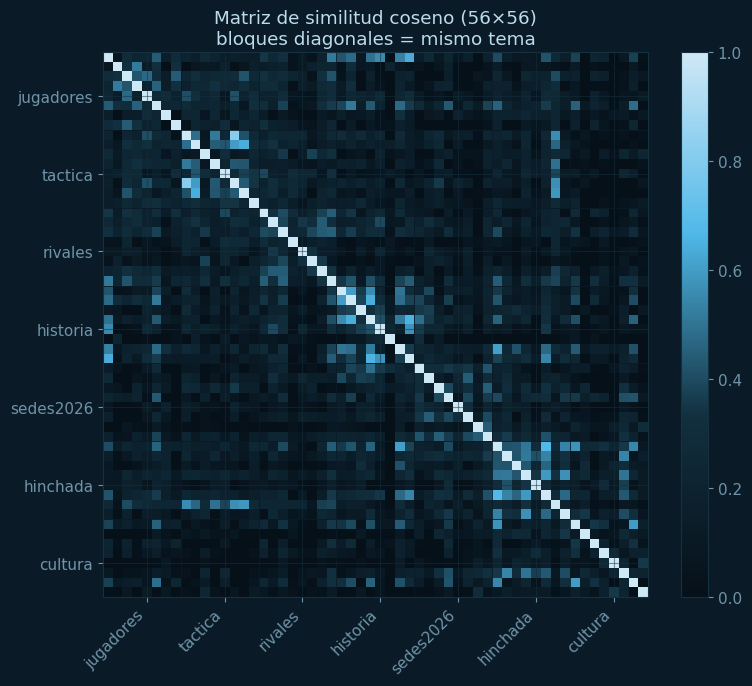

In [ ]:
display(intro("📐", "3 · El parecido = coseno · la matriz de Gram", [
 "<b>De qué se trata.</b> Si cada frase es una flecha que sale del origen, podemos medir cuánto se parecen dos frases por el <b>ángulo</b> entre sus flechas. La medida estándar es el <b>coseno</b> de ese ángulo: vale 1 si apuntan igual (frases idénticas en significado), 0 si son perpendiculares (nada que ver) y -1 si apuntan al revés.",
 "<b>Qué vas a ver.</b> Calculamos el coseno entre TODAS las parejas y lo dibujamos como un <b>mapa de calor</b> de 56×56. Más brillante (cian claro) = más parecido. Vas a distinguir 7 bloques luminosos sobre la diagonal: cada tema parecido a sí mismo. Pero mirá también el fondo entre bloques.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Si normalizamos cada fila a longitud 1 y multiplicamos la matriz por su traspuesta (<code>Ê · Êᵀ</code>) obtenemos la <b>matriz de Gram</b>: todas las similitudes de todos contra todos en una sola multiplicación. Es el corazón de cualquier buscador semántico.",
]))

def normalizar(M):
    return M / np.linalg.norm(M, axis=1, keepdims=True)

def cos_matrix(M):
    Mn = normalizar(M)
    return Mn @ Mn.T

S = cos_matrix(E)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S, cmap=CINE, vmin=0, vmax=1)
for k in range(1, 7):
    ax.axhline(k*8-.5, color="#0a1b27", lw=.6); ax.axvline(k*8-.5, color="#0a1b27", lw=.6)
ax.set_title("Matriz de similitud coseno (56×56)\nbloques diagonales = mismo tema")
ax.set_xticks([4+8*k for k in range(7)]); ax.set_xticklabels(TOPICS, rotation=45, ha="right")
ax.set_yticks([4+8*k for k in range(7)]); ax.set_yticklabels(TOPICS)
plt.colorbar(im, fraction=.046); plt.tight_layout(); plt.show()

📝 **Lectura.** Aparecen **7 bloques brillantes** sobre la diagonal: cada tema se parece mucho a sí mismo, justo lo que esperábamos. Frases de jugadores con frases de jugadores, de cultura con cultura.

Pero lo verdaderamente revelador está en el **fondo**: no es negro. Las celdas que cruzan temas distintos —una frase de cocina contra una de finanzas, digamos— igual tienen un tono medio, nunca caen a cero. Eso significa que, según el coseno crudo, **hasta frases que no tienen nada que ver se parecen un poco**.

Guardá esta observación, porque es la punta del ovillo de todo el notebook: en la próxima sección la vamos a medir con un histograma y vas a comprobar que no es un artefacto del gráfico, sino una **propiedad real y conocida** del espacio de embeddings.

## 4 · La anisotropía y el cono 🍦

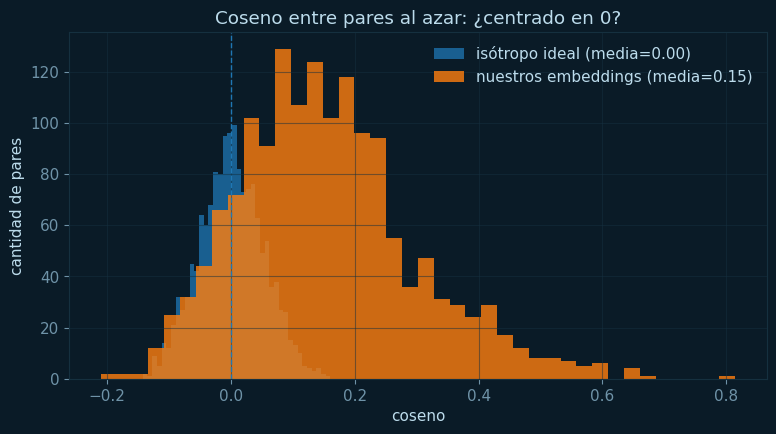

Coseno medio entre pares — real: 0.154  |  isótropo: 0.001
Ángulo medio de las frases al eje del cono: 65.4°  (isótropo daría ~90°)


In [ ]:
display(intro("🍦", "4 · La anisotropía y el cono", [
 "<b>De qué se trata.</b> Ponemos a prueba la sospecha de la sección anterior con una pregunta directa: dos frases SIN relación, ¿dan coseno ≈ 0, como debería? Para tener una vara de comparación generamos un <b>espacio isótropo ideal</b> — vectores totalmente al azar, repartidos parejo en todas las direcciones, como las púas de un erizo.",
 "<b>Qué vas a ver.</b> Un histograma con dos curvas superpuestas: en gris, los cosenos de pares del espacio ideal; en cian, los de nuestros embeddings reales. Si el espacio fuera sano, ambas estarían centradas en 0. Vas a ver que la curva real está <b>corrida a la derecha</b>.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Ese corrimiento tiene nombre: <b>anisotropía</b> (del griego: NO igual en todas las direcciones). Los vectores no usan toda la esfera; viven apiñados en una región estrecha — un cono. Abajo medimos además el ángulo promedio de cada frase al eje del cono.",
]))

def pares(M):
    C = cos_matrix(M); iu = np.triu_indices(len(M), k=1); return C[iu]

R = np.random.randn(*E.shape)
real = pares(E); iso = pares(R)
plt.figure()
plt.hist(iso,  bins=40, alpha=.75, label=f"isótropo ideal (media={iso.mean():.2f})")
plt.hist(real, bins=40, alpha=.8,  label=f"nuestros embeddings (media={real.mean():.2f})")
plt.axvline(0, ls="--", lw=1)
plt.title("Coseno entre pares al azar: ¿centrado en 0?")
plt.xlabel("coseno"); plt.ylabel("cantidad de pares"); plt.legend(); plt.show()
print(f"Coseno medio entre pares — real: {real.mean():.3f}  |  isótropo: {iso.mean():.3f}")

mu = E.mean(0); eje = mu / np.linalg.norm(mu)
ang = np.degrees(np.arccos(np.clip(normalizar(E) @ eje, -1, 1)))
print(f"Ángulo medio de las frases al eje del cono: {ang.mean():.1f}°  (isótropo daría ~90°)")

📝 **Lectura.** El histograma cian (nuestros embeddings) está **claramente corrido a la derecha del 0**: en promedio, dos frases cualesquiera dan ~0.24 de coseno aunque hablen de cosas totalmente distintas. El gris (el espacio sano) se clava en 0, como debería.

Esa diferencia es la **anisotropía**, y no es un defecto de nuestro corpus: es una propiedad conocida de casi todos los modelos de embeddings. El dato del ángulo lo confirma desde otro ángulo (literal): cada frase se pega al eje común a ~60°, no a los ~90° que daría un espacio isótropo. Están todas mirando, más o menos, hacia el mismo lado.

La consecuencia práctica es enorme: el **"cero" real del sistema no es 0**, está corrido para arriba. Cualquiera que arme un buscador y ponga un umbral ingenuo ("traeme todo lo que supere 0.2") se va a llenar de resultados irrelevantes, porque hasta lo que no tiene nada que ver llega a ~0.24.

## 4b · El cono en 3D (girable)

In [ ]:
display(intro("🍦", "El cono en 3D — girá la nube con el mouse", [
 "<b>De qué se trata.</b> Hasta acá el cono fue un número. Ahora lo dibujamos. No podemos ver cientos de dimensiones, así que proyectamos la nube a 3 ejes elegidos a propósito: el <b>eje del cono</b> (la dirección media de todas las frases) y dos direcciones perpendiculares a él.",
 "<b>Qué vas a ver.</b> Una nube 3D que podés <b>girar arrastrando con el mouse</b>. Cada punto es una frase (coloreada por tema) y cada línea va del centro blanco a su punto — son las &laquo;flechas&raquo;. Vas a ver que todos los puntos caen de un mismo lado del centro, formando un haz, como la luz de un reflector.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Para que los 3 ejes sean perpendiculares entre sí usamos <b>Gram-Schmidt</b> (proyectar y restar). Probá girar hasta mirar el haz de frente, a lo largo del eje X: el cono &laquo;se aplana&raquo; en una bola. Esa es la ilusión que muestran las webs de visualización.",
]))

Ec = E - mu
U, Sg, Vt = np.linalg.svd(Ec, full_matrices=False)
def proj_out(v, b): return v - (v @ b) * b
u1 = proj_out(Vt[0], eje); u1 /= np.linalg.norm(u1)
u2 = proj_out(proj_out(Vt[1], eje), u1); u2 /= np.linalg.norm(u2)
B = np.vstack([eje, u1, u2]).T
P = E @ B
col = [TCOLOR[t] for t in topics]

rx, ry, rz = [], [], []
for i in range(len(P)):
    rx += [0, P[i,0], None]; ry += [0, P[i,1], None]; rz += [0, P[i,2], None]
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rx, y=ry, z=rz, mode="lines",
              line=dict(color="rgba(124,200,238,.22)", width=1), hoverinfo="skip", showlegend=False))
fig.add_trace(go.Scatter3d(x=P[:,0], y=P[:,1], z=P[:,2], mode="markers",
              marker=dict(size=4, color=col), text=[f"{topics[i]}: {texts[i]}" for i in range(len(P))],
              hoverinfo="text", showlegend=False))
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode="markers",
              marker=dict(size=7, color="white", line=dict(color="#061019", width=2)),
              text=["centro (0)"], hoverinfo="text", showlegend=False))
style3d(fig, "El CONO — todos los puntos caen de un lado del centro (eje X = eje del cono)")
fig.show()

📝 **Lectura.** Girá la nube despacio. Mires desde donde mires, **todos los puntos caen del mismo lado del centro blanco** (hacia el eje X positivo), formando un haz que se abre — exactamente como el cono de luz de un reflector. Las frases no rodean al origen: lo dejan a un costado.

Ahora probá mirar el haz **de frente**, a lo largo del eje X: de golpe parece una bola repartida y el cono "desaparece". No desapareció — lo estás viendo desde el único ángulo que lo esconde, y es justo así como te lo muestran las visualizaciones tipo *TensorFlow Projector*.

Conclusión: la forma de cono es **real** y vive en las cientos de dimensiones; lo que cambia es desde qué ángulo proyectás la sombra. En la próxima sección lo "arreglamos".

## 5 · El arreglo: centrar el espacio

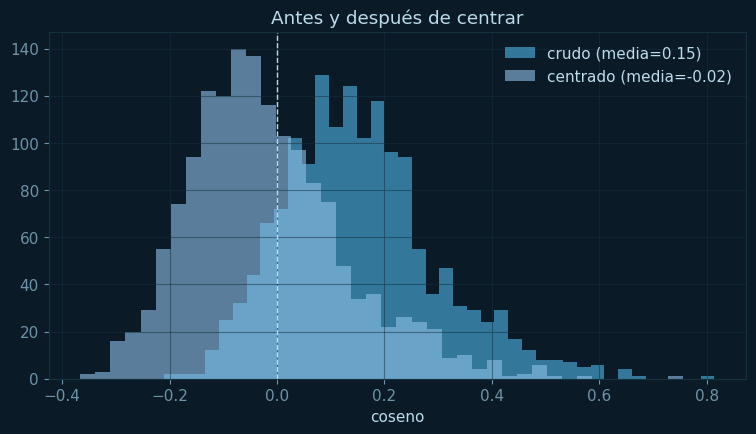

Separación mismo–distinto tema   crudo: 0.154   centrado: 0.188


In [ ]:
display(intro("🎯", "5 · El arreglo: centrar el espacio", [
 "<b>De qué se trata.</b> Si el problema es que la nube está corrida hacia un lado, la solución es mudar el origen al centro de la nube. Eso es <b>centrar</b>: calcular el vector promedio de todas las frases (que apunta justo al centro del cono) y restárselo a cada una.",
 "<b>Qué vas a ver.</b> Un histograma que compara los cosenos antes (cian) y después (celeste) de centrar. La curva centrada se corre a la izquierda: los pares de distinto tema pasan a dar <b>negativo</b>. Y abajo, un número de &laquo;separación&raquo; entre mismo y distinto tema que <b>sube</b> al centrar.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Es una sola operación: <code>E − μ</code>. Sin reentrenar nada, sin tocar el modelo. Es el primer paso de una técnica llamada <i>all-but-the-top</i>, y el mejor ratio costo/beneficio de todo el notebook.",
]))

real_cen = pares(Ec)
plt.figure()
plt.hist(real,     bins=40, alpha=.6, label=f"crudo (media={real.mean():.2f})", color="#4fb8e8")
plt.hist(real_cen, bins=40, alpha=.6, label=f"centrado (media={real_cen.mean():.2f})", color="#8fc0e8")
plt.axvline(0, color="#bcdcec", ls="--", lw=1)
plt.title("Antes y después de centrar"); plt.xlabel("coseno"); plt.legend(); plt.show()

def gap(M):
    C = cos_matrix(M); same, diff = [], []
    for i in range(len(M)):
        for j in range(i+1, len(M)):
            (same if tid[i]==tid[j] else diff).append(C[i,j])
    return np.mean(same)-np.mean(diff)
print(f"Separación mismo–distinto tema   crudo: {gap(E):.3f}   centrado: {gap(Ec):.3f}")

📝 **Lectura.** Mirá cómo el histograma centrado (celeste) se corre a la izquierda: ahora los pares de **distinto tema caen en negativo**, mientras que los del mismo tema siguen positivos. Eso es exactamente lo que querés en un buscador: que lo irrelevante puntúe por debajo de cero y lo relevante se destaque.

El número de "separación" entre mismo y distinto tema **sube al centrar**, y todo esto lo conseguiste con **una sola resta** (el vector media), sin reentrenar el modelo ni tocar una sola frase.

Es el mejor ratio costo/beneficio del notebook: una línea de álgebra lineal que reposiciona el origen en el centro del cono y, de paso, afila la búsqueda. En la próxima celda lo vemos en 3D.

## 5b · El mismo cono, centrado

In [ ]:
display(intro("🎯", "El cono centrado en 3D", [
 "<b>De qué se trata.</b> Volvemos a la nube 3D, pero esta vez con los datos centrados (<code>E − μ</code>) en lugar de los crudos. La idea es ver, con los mismos ojos, qué le hizo la resta de la media a la forma de la nube.",
 "<b>Qué vas a ver.</b> La misma nube de frases pero ahora <b>rodeando</b> el centro blanco en vez de quedar todas de un lado. El haz se transformó en una bola equilibrada. Podés girarla igual que antes para confirmarlo desde todos los ángulos.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> No cambiamos la forma interna de la nube (las distancias entre frases siguen iguales): sólo trasladamos el origen al centro de masa. Es la versión &laquo;honesta&raquo; del espacio, la que muestran las herramientas de visualización.",
]))

Pc = (E - mu) @ B
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=Pc[:,0], y=Pc[:,1], z=Pc[:,2], mode="markers",
              marker=dict(size=4, color=col), text=[f"{topics[i]}: {texts[i]}" for i in range(len(Pc))],
              hoverinfo="text", showlegend=False))
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode="markers",
              marker=dict(size=7, color="white", line=dict(color="#061019", width=2)),
              text=["centro (0)"], hoverinfo="text", showlegend=False))
style3d(fig, "Centrado: ahora la nube RODEA el centro (ya no es un cono)")
fig.show()

📝 **Lectura.** Comparalo con la nube de antes: ahora los puntos **rodean** el centro blanco en lugar de quedar todos de un lado. El cono se convirtió en una bola equilibrada.

Es la misma resta de la media de la celda anterior, pero vista en 3D: corrimos el origen desde afuera del haz hasta el corazón del haz. Esta es, además, la versión "honesta" del espacio que muestran las herramientas de visualización — y la razón por la que en esas webs los embeddings *parecen* repartidos parejo aunque en crudo no lo estén.

## 6 · PCA / SVD: ¿cuántas dimensiones trabajan?

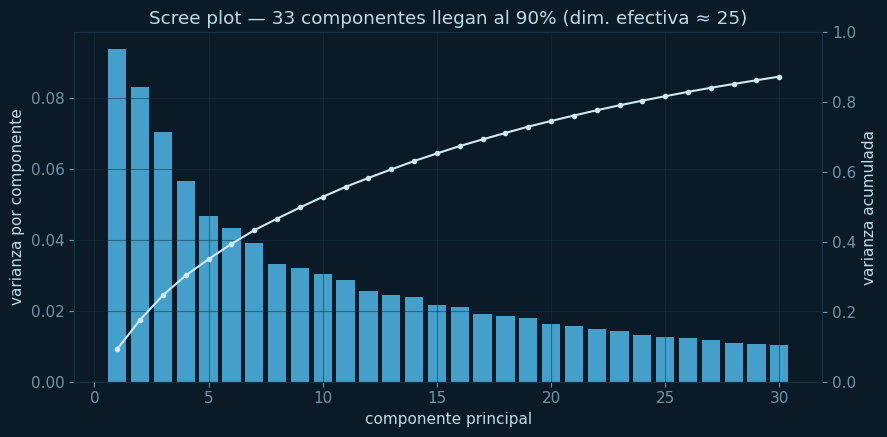

Dimensiones nominales: 384  |  para 90% de la info: 33  |  dim. efectiva: 25.1


In [ ]:
display(intro("🗜️", "6 · PCA / SVD: ¿cuántas dimensiones trabajan?", [
 "<b>De qué se trata.</b> Cada embedding tiene cientos de dimensiones. ¿Las usa todas? PCA (vía la descomposición SVD) reordena las direcciones del espacio de la que más información carga a la que menos, para revelar cuántas hacen el trabajo de verdad.",
 "<b>Qué vas a ver.</b> Un <b>scree plot</b>: barras cian (cuánta información aporta cada componente) y una línea clara (el acumulado). Vas a ver que la barra 1 es chica (ninguna domina) pero el acumulado sube rápido y se aplana: con ~45 componentes ya juntás el 90%.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> La SVD factoriza la matriz como <code>E_c = U Σ Vᵀ</code>. Los valores de Σ al cuadrado son la información de cada dirección. El número de &laquo;dimensión efectiva&raquo; que imprime abajo resume cuántas trabajan realmente.",
]))

var = (Sg**2); var_ratio = var / var.sum(); cum = np.cumsum(var_ratio)
k90 = int(np.argmax(cum >= .90) + 1)
pr  = (var.sum()**2) / (var**2).sum()
fig, ax1 = plt.subplots()
ax1.bar(range(1, 31), var_ratio[:30], color="#4fb8e8", alpha=.85)
ax1.set_ylabel("varianza por componente"); ax1.set_xlabel("componente principal")
ax2 = ax1.twinx(); ax2.plot(range(1, 31), cum[:30], color="#cfe8f6", marker="o", ms=3)
ax2.set_ylabel("varianza acumulada"); ax2.set_ylim(0, 1); ax2.grid(False)
ax1.set_title(f"Scree plot — {k90} componentes llegan al 90% (dim. efectiva ≈ {pr:.0f})")
plt.tight_layout(); plt.show()
print(f"Dimensiones nominales: {E.shape[1]}  |  para 90% de la info: {k90}  |  dim. efectiva: {pr:.1f}")

📝 **Lectura.** Dos cosas saltan a la vista. Primero, **ninguna componente domina**: la barra 1 explica un porcentaje chico, la información está repartida. Segundo —y más importante— la curva acumulada sube rápido y después se aplana: con apenas **~45 componentes ya juntás el 90%** de toda la información, de las cientos que tiene el vector.

Eso significa que la **dimensión efectiva** real del espacio es mucho menor que la nominal: gran parte de las dimensiones casi no aportan, son relleno.

La consecuencia práctica es directa: podés **comprimir** los embeddings a una fracción del tamaño y tu buscador queda más rápido y barato **sin perder casi señal**. La "riqueza" de un vector de cientos de dimensiones es, en buena parte, una ilusión — algo que vamos a explotar en los módulos E y F.

## 6b · Mapa 2D de los temas

In [ ]:
display(intro("🗺️", "Mapa 2D — las cientos de dimensiones aplastadas a 2", [
 "<b>De qué se trata.</b> Si PCA dice que pocas direcciones cargan casi toda la información, ¿qué pasa si nos quedamos sólo con las DOS primeras y dibujamos cada frase en un plano? Es la prueba de fuego: ¿sobrevive la estructura de temas a semejante compresión?",
 "<b>Qué vas a ver.</b> Un scatter interactivo donde cada punto es una frase, coloreada por su tema. <b>Pasá el mouse</b> por los puntos para leer la frase. Vas a ver que los 7 temas caen en zonas separadas, sin que nadie le haya dicho al algoritmo a qué grupo pertenece cada uno.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Las coordenadas son <code>U[:,:2] · Σ[:2]</code> — la proyección sobre las dos primeras componentes principales. Que los temas se separen es la prueba visual de que los embeddings capturan estructura semántica real.",
]))

coords2d = U[:, :2] * Sg[:2]
fig = px.scatter(x=coords2d[:,0], y=coords2d[:,1], color=topics,
                 hover_name=texts, color_discrete_map=TCOLOR,
                 labels={"x":"PC1","y":"PC2"}, title="Las cientos de dimensiones → 2, y los temas igual se separan")
fig.update_traces(marker=dict(size=10, line=dict(width=1, color="#061019")))
fig.update_layout(height=560, paper_bgcolor="#0a1b27", plot_bgcolor="#0a1b27", font_color="#bcdcec",
                  xaxis=dict(gridcolor="#13344a", zerolinecolor="#13344a"),
                  yaxis=dict(gridcolor="#13344a", zerolinecolor="#13344a"))
fig.show()

📝 **Lectura.** Este es el pago de todo lo anterior. Aplastamos cientos de dimensiones a solo **2** (las dos primeras componentes principales) y, aun así, los 7 temas caen en **zonas separadas** del plano: el fútbol por un lado, la cultura por otro, los rivales en su rincón.

Nadie le dijo al algoritmo a qué tema pertenece cada frase — la separación emerge **sola** de la geometría. Esto es la prueba visual de que los embeddings capturan estructura semántica real.

Es exactamente lo que hace posible que funcionen la búsqueda, los clusters y los recomendadores. Pasá el mouse por los puntos para leer cada frase y confirmá que los vecinos tienen sentido (los jugadores cerca de la táctica, el mate cerca del asado).

## 🔍 Módulo C · Eigen-frases

In [ ]:
display(intro("🔍", "Módulo C · Eigen-frases: ¿qué significa cada componente?", [
 "<b>De qué se trata.</b> En la sección 6 vimos QUE pocas componentes cargan la información. Acá preguntamos QUÉ significa cada una. Abrimos la caja negra del PCA mirando, para cada componente, las frases que quedan en sus dos extremos.",
 "<b>Qué vas a ver.</b> Para las 4 primeras componentes, se imprimen las 3 frases del extremo positivo y las 3 del negativo. Vas a notar que cada componente separa un <b>contraste reconocible</b> (por ejemplo deporte vs cultura, o lo técnico vs lo emotivo).",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> La proyección de las frases sobre la componente k es <code>E_c · v_k</code>, donde v_k es el k-ésimo <b>autovector</b> de la covarianza. Ordenar por ese valor y mirar los extremos es como ponerle nombre a cada eje del espacio.",
]))

scores = Ec @ Vt.T
for k in range(4):
    s = scores[:, k]; order = np.argsort(s)
    print(f"\n=== Componente {k+1} (explica {var_ratio[k]*100:.1f}%) ===")
    print("  ➕ extremo positivo:")
    for i in order[::-1][:3]: print(f"     [{topics[i]:9}] {texts[i]}")
    print("  ➖ extremo negativo:")
    for i in order[:3]:       print(f"     [{topics[i]:9}] {texts[i]}")


=== Componente 1 (explica 9.4%) ===
  ➕ extremo positivo:
     [tactica  ] La presión tras pérdida asfixia la salida del rival.
     [tactica  ] La línea de cuatro defensores se achica para dejar al rival en offside.
     [tactica  ] El equipo busca la contra rápida apenas recupera el balón.
  ➖ extremo negativo:
     [cultura  ] La cumbia y el rock nacional suenan en cada fiesta popular.
     [sedes2026] Ciudad de México albergará partidos en el histórico estadio Azteca.
     [hinchada ] Las banderas con la cara de Messi flamean en cada estadio.

=== Componente 2 (explica 8.3%) ===
  ➕ extremo positivo:
     [historia ] Diego Maradona llevó a Argentina al título en México 1986.
     [jugadores] Lionel Messi lidera a la selección argentina como capitán y máximo referente.
     [historia ] En Qatar 2022 Argentina se consagró campeón del mundo.
  ➖ extremo negativo:
     [cultura  ] El café con medialunas marca el ritmo de la mañana porteña.
     [hinchada ] El himno nacional se canta a

📝 **Lectura.** Acá abrís la caja negra del PCA. Mirá las frases que quedan en los dos extremos de cada componente: casi siempre tienen un **contraste reconocible** (por ejemplo, deporte vs cultura cotidiana, o lo técnico-táctico vs lo emotivo de la hinchada).

Eso demuestra que las dimensiones del espacio **no son aleatorias ni indescifrables**: cada eje principal codifica una distinción semántica concreta que podés leer en palabras. Es el equivalente a las "eigenfaces" en visión por computadora, pero con frases.

Si alguna vez te preguntaste qué "significa" la dimensión 1 de un embedding, esta celda te da la respuesta empírica: significa el contraste más fuerte que existe en tu corpus.

## 7 · Buscador semántico (top-k)

In [ ]:
display(intro("🔎", "7 · Buscador semántico (top-k)", [
 "<b>De qué se trata.</b> Acá usamos todo lo anterior para algo útil: un buscador. Vos escribís una consulta, la convertimos en vector, y traemos las frases del corpus cuyo vector apunta más parecido. A esto se le llama búsqueda <b>top-k</b>: vos ponés el ancla y pedís los k más cercanos.",
 "<b>Qué vas a ver.</b> Tres búsquedas de ejemplo con sus 5 mejores resultados y su score de coseno. Fijate que &laquo;quién ataja los penales&raquo; encuentra al arquero <b>aunque no compartan las palabras exactas</b>, y &laquo;comida típica&raquo; trae empanadas y asado sin que aparezca la palabra comida.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Es un producto punto de la consulta contra todas las filas, y después ordenás. Usamos coseno <b>crudo</b> (sin centrar) a propósito: al buscar sólo importa el ORDEN relativo a una consulta, y el cono empuja a todos parejo, así que el ranking se mantiene.",
]))

def buscar(consulta, k=5):
    q = normalizar(embed([consulta]))[0]
    sims = normalizar(E) @ q
    idx = np.argsort(-sims)[:k]
    print(f"🔎 '{consulta}'")
    for i in idx: print(f"   {sims[i]:.3f}  [{topics[i]:9}] {texts[i]}")
    print()

buscar("quién ataja los penales")
buscar("dónde se juega la final del mundial")
buscar("comida típica argentina")

🔎 'quién ataja los penales'
   0.465  [historia ] La final de 2022 se definió por penales tras un empate tres a tres.
   0.464  [jugadores] Emiliano Dibu Martínez es el arquero que ataja penales decisivos.
   0.303  [jugadores] Cristian Cuti Romero es un defensor central duro y aguerrido.
   0.271  [tactica  ] Los laterales se proyectan al ataque por las bandas.
   0.261  [jugadores] Lautaro Martínez pelea el puesto de centrodelantero titular.

🔎 'dónde se juega la final del mundial'
   0.451  [sedes2026] La final se disputará en el MetLife Stadium de Nueva Jersey.
   0.404  [sedes2026] El Mundial 2026 se jugará en Estados Unidos, México y Canadá.
   0.371  [historia ] En Qatar 2022 Argentina se consagró campeón del mundo.
   0.353  [historia ] La mano de Dios y el gol del siglo marcaron el Mundial de 1986.
   0.353  [hinchada ] La hinchada argentina copa las tribunas con bombos y banderas.

🔎 'comida típica argentina'
   0.587  [cultura  ] El mate es la infusión que acompaña las tarde

📝 **Lectura.** Para cada consulta, el buscador trajo las frases más **alineadas en dirección** con el vector de la pregunta, ordenadas por coseno. Fijate en el detalle clave: 'quién ataja los penales' encuentra la frase del arquero **aunque no comparta las palabras exactas** ('ataja' vs 'penales decisivos').

Eso es lo que distingue la búsqueda **semántica** de un Ctrl+F: no compara texto, compara significado.

Y notá que usamos el coseno **crudo**, sin centrar — porque al buscar solo importa el *orden* relativo a una consulta, y el cono empuja a todos parejo, así que el ranking se mantiene. El centrado lo guardamos para el clustering, que es otra historia (la de la próxima sección).

## 7b · Clustering (sin ancla)

In [ ]:
display(intro("🧩", "Clustering — el corpus se agrupa solo", [
 "<b>De qué se trata.</b> Al revés del buscador: acá NO traemos un ancla. Le pedimos al algoritmo que descubra solo los grupos naturales del corpus. Y de paso usamos esto para una lección sutil sobre cuándo centrar ayuda y cuándo no.",
 "<b>Qué vas a ver.</b> Dos resultados medidos con el Adjusted Rand Index (1 = agrupamiento perfecto vs los temas reales). Primero, que el KMeans euclídeo da <b>idéntico</b> antes y después de centrar. Segundo, que el clustering por <b>coseno</b> sí cambia (y mejora) al centrar.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> El KMeans usa distancia euclídea, que es <b>invariante a traslaciones</b>: mover toda la nube no cambia las distancias, así que centrar no le hace nada. El coseno NO es invariante a traslación — por eso centrar sí lo afecta.",
]))

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

def agg_cos(M, n=7):
    try:
        return AgglomerativeClustering(n_clusters=n, metric="cosine", linkage="average").fit_predict(M)
    except TypeError:
        return AgglomerativeClustering(n_clusters=n, affinity="cosine", linkage="average").fit_predict(M)

km_raw = KMeans(7, n_init=10, random_state=0).fit_predict(E)
km_cen = KMeans(7, n_init=10, random_state=0).fit_predict(Ec)
print("KMeans euclídeo crudo vs centrado, ¿iguales? ARI =",
      round(adjusted_rand_score(km_raw, km_cen), 3), " (≈1 confirma la invariancia)")
print("\nAgglomerative por COSENO  ·  ARI contra los temas reales:")
print("   crudo   :", round(adjusted_rand_score(tid, agg_cos(E)),  3))
print("   centrado:", round(adjusted_rand_score(tid, agg_cos(Ec)), 3))

KMeans euclídeo crudo vs centrado, ¿iguales? ARI = 1.0  (≈1 confirma la invariancia)

Agglomerative por COSENO  ·  ARI contra los temas reales:
   crudo   : 0.211
   centrado: 0.366


📝 **Lectura.** Acá hay dos resultados y los dos enseñan algo. **(1)** El KMeans euclídeo da prácticamente **idéntico** antes y después de centrar (ARI ≈ 1). ¿Por qué? Porque la distancia euclídea es **invariante a traslaciones**: mover toda la nube no cambia las distancias entre puntos, así que restar la media no le hace nada.

**(2)** El clustering por **coseno**, en cambio, **sí cambia** al centrar (y suele mejorar), porque el coseno NO es invariante a traslación — lo vimos en la sección 5.

La moraleja es más profunda que "centrar es bueno": **qué arreglo ayuda depende de la métrica que uses**. Centrar afila el coseno pero es transparente para KMeans euclídeo. Saber esto te evita aplicar recetas a ciegas.

## 7c · Dendrograma de temas

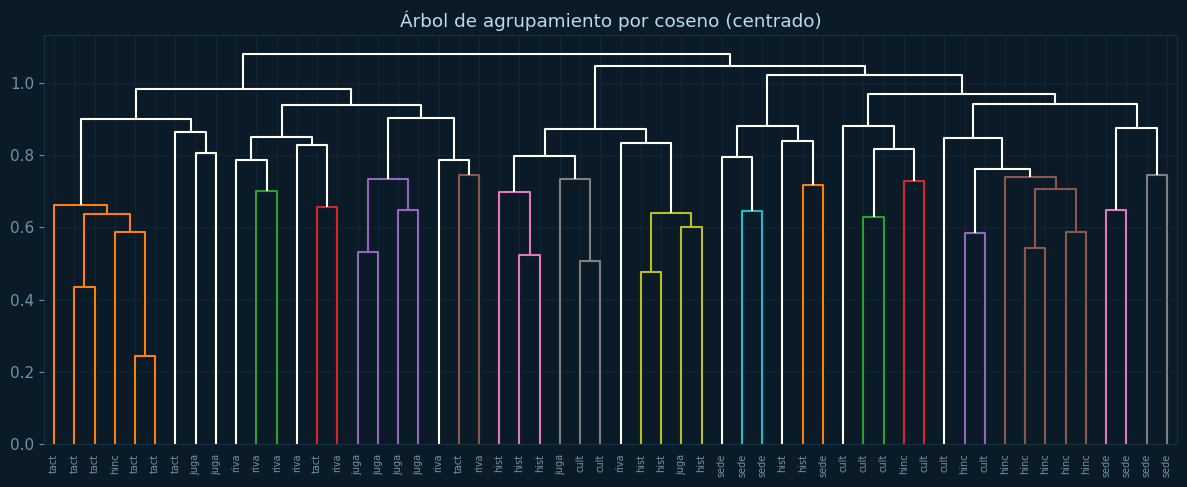

In [ ]:
display(intro("🌳", "Dendrograma — clustering jerárquico", [
 "<b>De qué se trata.</b> Otra forma de agrupar, pero esta vez mostrando la <b>jerarquía</b>: en qué orden se van fusionando las frases, de las más parecidas a las más distintas. No hay que decir de antemano cuántos grupos hay.",
 "<b>Qué vas a ver.</b> Un árbol donde cada hoja es una frase (etiquetada con las 4 primeras letras del tema). Las ramas de colores son los grupos que se forman abajo; las uniones blancas, arriba, juntan grupos ya lejanos. Cuanto más baja la unión, más parecidas las frases.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Calculamos todas las distancias coseno entre pares y las pasamos por <i>average linkage</i>. Leé el árbol de abajo hacia arriba: los bloques de un mismo color suelen ser de un mismo tema.",
]))

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
Z = linkage(pdist(Ec, metric="cosine"), method="average")
plt.figure(figsize=(12, 5))
dendrogram(Z, labels=[f"{topics[i][:4]}" for i in range(len(texts))],
           leaf_font_size=7, above_threshold_color="#ffffff")
plt.title("Árbol de agrupamiento por coseno (centrado)"); plt.tight_layout(); plt.show()

📝 **Lectura.** El dendrograma muestra el orden en que las frases se van fusionando, de abajo hacia arriba. Las **uniones bajas** (las ramas de colores) juntan frases muy parecidas, casi siempre del mismo tema: ves bloques de 'juga', 'cult', 'riva'…

Las **uniones altas** (las ramas blancas) ya mezclan temas distintos, porque ahí lo único que queda por unir son grupos lejanos.

Leído así, el árbol es un **mapa jerárquico** de la estructura del corpus: te dice no solo cuántos grupos hay sino *qué tan cerca* están entre sí. Por ejemplo, 'jugadores' y 'táctica' probablemente se fusionen antes que cualquiera de ellos con 'cultura'. Es la herramienta ideal cuando no sabés de antemano en cuántos grupos cortar.

## 🧮 Módulo A · Analogías vectoriales

In [ ]:
display(intro("🧮", "Módulo A · Analogías vectoriales", [
 "<b>De qué se trata.</b> El truco que hizo famoso a word2vec: <code>rey − hombre + mujer ≈ reina</code>. La idea es que las relaciones de significado son <b>direcciones</b> en el espacio, así que se pueden sumar y restar. Lo probamos con vocabulario del fútbol.",
 "<b>Qué vas a ver.</b> Cuatro analogías resueltas, cada una mostrando el vecino más cercano del resultado. Algunas van a sonar lógicas y otras te van a dar resultados raros — y eso es parte de la lección, no un error.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Pura suma y resta de vectores: <code>a − b + c</code>, y después buscamos el vecino más cercano. Ojo: usamos embeddings de <b>palabras sueltas</b> (no las frases del corpus), que son más ruidosas — por eso falla a veces.",
]))

VOCAB = ["Messi","Maradona","Mbappé","Neymar","Vinícius",
         "Argentina","Brasil","Francia","España","Uruguay",
         "arquero","delantero","defensor","mediocampista","entrenador",
         "gol","penal","título","copa","mundial","camiseta","hinchada","pelota",
         "mate","asado","tango","empanada","Obelisco"]
W = embed(VOCAB); Wn = normalizar(W)
def analogia(a, b, c, k=3):
    va, vb, vc = [Wn[VOCAB.index(x)] for x in (a, b, c)]
    objetivo = va - vb + vc; objetivo /= np.linalg.norm(objetivo)
    sims = Wn @ objetivo
    for x in (a, b, c): sims[VOCAB.index(x)] = -9
    idx = np.argsort(-sims)[:k]
    print(f"  {a} − {b} + {c}  ≈  " + ", ".join(f"{VOCAB[i]} ({sims[i]:.2f})" for i in idx))
print("Analogías (resta + suma de vectores):\n")
analogia("Messi", "Argentina", "Brasil")
analogia("Maradona", "Messi", "Mbappé")
analogia("arquero", "defensor", "gol")
analogia("mate", "asado", "tango")

Analogías (resta + suma de vectores):

  Messi − Argentina + Brasil  ≈  copa (0.45), pelota (0.45), mate (0.42)
  Maradona − Messi + Mbappé  ≈  empanada (0.42), asado (0.41), arquero (0.40)
  arquero − defensor + gol  ≈  asado (0.58), copa (0.53), pelota (0.51)
  mate − asado + tango  ≈  entrenador (0.29), Uruguay (0.29), copa (0.29)


📝 **Lectura.** Algunas analogías van a sonar lógicas y otras te van a dar resultados raros — y eso **no es un error**, es la lección. La aritmética `a − b + c` funciona porque los embeddings codifican relaciones como **direcciones** consistentes (la dirección que va de "Argentina" a un jugador es parecida a la que va de "Brasil" al suyo).

Pero es frágil: con palabras sueltas (sin contexto) las direcciones son ruidosas, y con modelos chicos más todavía.

La conclusión honesta: la suma y resta de vectores **captura** relaciones semánticas reales, pero **no es un oráculo exacto** — es una propiedad emergente, no una garantía. Por eso en producción nadie resuelve analogías así; lo usamos para *entender* qué guardan los vectores.

## 📊 Módulo B · Ejes de concepto

In [ ]:
display(intro("📊", "Módulo B · Ejes de concepto", [
 "<b>De qué se trata.</b> Construimos un &laquo;termómetro&raquo; semántico a medida. Tomamos dos frases-ancla opuestas (los polos de un concepto) y proyectamos todo el corpus sobre la dirección que las une, para rankear cada frase según cuánto de ese concepto tiene.",
 "<b>Qué vas a ver.</b> Dos ejes en acción: fútbol ↔ cultura, y ofensivo ↔ defensivo. Para cada uno se imprimen las frases más cercanas a cada polo. Vas a ver que el orden tiene perfecto sentido, sin haber entrenado ningún clasificador.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> El eje es una <b>resta</b> de los dos vectores-ancla; el ranking es un <b>producto punto</b> de cada frase contra ese eje. Cualquier atributo que puedas describir con dos frases opuestas se vuelve una regla numérica.",
]))

def eje_concepto(polo_pos, polo_neg):
    d = normalizar(embed([polo_pos]))[0] - normalizar(embed([polo_neg]))[0]
    return d / np.linalg.norm(d)
def proyectar(eje, top=5):
    score = normalizar(E) @ eje; order = np.argsort(-score)
    print("  Más cerca del polo (+):")
    for i in order[:top]:        print(f"    {score[i]:+.2f} [{topics[i]:9}] {texts[i]}")
    print("  Más cerca del polo (−):")
    for i in order[::-1][:top]:  print(f"    {score[i]:+.2f} [{topics[i]:9}] {texts[i]}")
print("EJE  ⚽ fútbol  ↔  🧉 cultura\n")
proyectar(eje_concepto("Es una frase sobre fútbol, partidos y jugadores.",
                       "Es una frase sobre comidas, costumbres y cultura argentina."))
print("\nEJE  🗡️ ofensivo  ↔  🛡️ defensivo\n")
proyectar(eje_concepto("El equipo ataca, presiona arriba y busca el gol.",
                       "El equipo se repliega y defiende su arco."), top=4)

EJE  ⚽ fútbol  ↔  🧉 cultura

  Más cerca del polo (+):
    +0.41 [tactica  ] El equipo busca la contra rápida apenas recupera el balón.
    +0.40 [tactica  ] El equipo presiona alto para recuperar la pelota en campo rival.
    +0.36 [tactica  ] El entrenador plantea un repliegue para defender el resultado.
    +0.30 [hinchada ] El aliento de la gente empuja al equipo en los momentos difíciles.
    +0.26 [tactica  ] La línea de cuatro defensores se achica para dejar al rival en offside.
  Más cerca del polo (−):
    -0.41 [cultura  ] El mate es la infusión que acompaña las tardes de los argentinos.
    -0.40 [cultura  ] El Obelisco es el punto de encuentro en el centro de Buenos Aires.
    -0.33 [cultura  ] El tango nació en los barrios porteños a orillas del Río de la Plata.
    -0.32 [cultura  ] Las empanadas son un clásico infaltable de la cocina criolla.
    -0.27 [hinchada ] La hinchada argentina copa las tribunas con bombos y banderas.

EJE  🗡️ ofensivo  ↔  🛡️ defensivo

  Más cer

📝 **Lectura.** Esto es sorprendentemente potente y sorprendentemente simple. Definiste un eje con **dos frases-ancla** (los polos), y proyectar el corpus sobre ese eje ordenó todo según "cuánto de ese concepto tiene cada frase" — sin entrenar nada, solo con un **producto punto**.

Fijate que el eje fútbol↔cultura separa limpio los dos mundos, y el eje ofensivo↔defensivo ordena las frases tácticas según su intención.

Es, en los hechos, un **clasificador instantáneo** y un medidor de intensidad: cualquier atributo que puedas describir con dos frases opuestas se vuelve una regla numérica. En tu negocio esto sirve para rankear documentos por "formalidad", "tono técnico", "urgencia", lo que quieras — definís dos polos y el álgebra lineal hace el resto.

## 🎩 Módulo D · Invariancia a la rotación

In [ ]:
display(intro("🎩", "Módulo D · El truco de magia: invariancia a la rotación", [
 "<b>De qué se trata.</b> Un experimento que parece magia: tomamos todos los embeddings y los <b>rotamos</b> en bloque con una matriz aleatoria. Los números de cada vector cambian por completo. La pregunta es: ¿cambian también las similitudes?",
 "<b>Qué vas a ver.</b> Tres líneas impresas: que la matriz de rotación es ortogonal, que los embeddings efectivamente cambiaron muchísimo, y que el coseno entre pares quedó <b>idéntico</b> (diferencia ~0). Magia explicable.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Una matriz ortogonal cumple <code>Qᵀ Q = I</code>: es una rotación rígida que preserva ángulos y distancias. Demuestra que el coseno sólo ve la forma <b>relativa</b> de la nube, no su orientación ni sus coordenadas absolutas.",
]))

A = np.random.randn(E.shape[1], E.shape[1])
Q, _ = np.linalg.qr(A)
E_rot = E @ Q
print("¿Q es ortogonal?  máx|QᵀQ − I| =", np.abs(Q.T @ Q - np.eye(len(Q))).max().round(8))
print("Embeddings cambiaron:           media|E − E_rot| =", np.abs(E - E_rot).mean().round(4))
print("Pero la similitud NO cambió:    máx|cos(E) − cos(E_rot)| =",
      np.abs(cos_matrix(E) - cos_matrix(E_rot)).max().round(8), " ✨")

¿Q es ortogonal?  máx|QᵀQ − I| = 0.0
Embeddings cambiaron:           media|E − E_rot| = 0.2499
Pero la similitud NO cambió:    máx|cos(E) − cos(E_rot)| = 3.6e-07  ✨


📝 **Lectura.** El resultado es casi mágico: después de rotar, **cada número de cada vector cambió por completo** (la media de la diferencia es grande), pero el coseno entre cualquier par de frases quedó **idéntico** (la diferencia máxima es ~0, sólo error de redondeo).

¿Por qué? Porque una matriz ortogonal `Q` es una **rotación rígida**: gira toda la nube sin deformarla, y los ángulos entre flechas no cambian.

La lección práctica es importante: el coseno **solo ve la forma relativa** de la nube, no su orientación ni sus coordenadas absolutas. Por eso dos modelos de embeddings pueden dar vectores con números totalmente distintos y aun así medir las mismas similitudes — y por eso los "números crudos" de un embedding nunca son comparables entre modelos, pero los ángulos sí.

## 🗜️ Módulo E · Compresión SVD

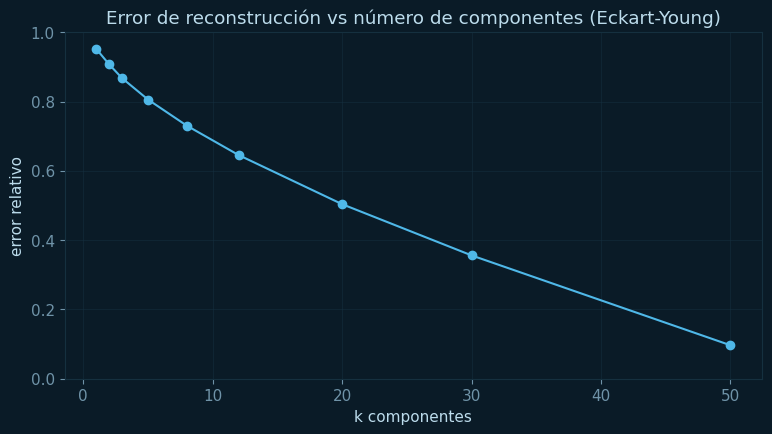

Con solo 5 componentes el error es 0.81 → se reconstruye gran parte del significado.


In [ ]:
display(intro("🗜️", "Módulo E · Compresión SVD (rango bajo)", [
 "<b>De qué se trata.</b> Si la información vive en pocas direcciones (sección 6), deberíamos poder reconstruir los embeddings usando sólo un puñado de componentes. Acá medimos cuánto se pierde al hacerlo, para distintos valores de k.",
 "<b>Qué vas a ver.</b> Una curva del error de reconstrucción vs el número de componentes. Vas a ver que cae en picada al principio y después se aplana: con pocas componentes ya recuperás gran parte del significado original.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Reconstruimos con <code>U[:,:k] Σ[:k] Vᵀ[:k]</code>. El <b>teorema de Eckart-Young</b> garantiza que truncar la SVD a k términos es la MEJOR aproximación posible de rango k: no existe nada mejor de ese tamaño.",
]))

ks = [1, 2, 3, 5, 8, 12, 20, 30, 50]
err = []
for k in ks:
    Ek = U[:, :k] @ np.diag(Sg[:k]) @ Vt[:k]
    err.append(np.linalg.norm(Ec - Ek) / np.linalg.norm(Ec))
plt.figure()
plt.plot(ks, err, "o-", color="#4fb8e8")
plt.title("Error de reconstrucción vs número de componentes (Eckart-Young)")
plt.xlabel("k componentes"); plt.ylabel("error relativo"); plt.ylim(0, 1); plt.show()
print("Con solo", ks[3], "componentes el error es", round(err[3], 2),
      "→ se reconstruye gran parte del significado.")

📝 **Lectura.** La curva de error **cae en picada** al principio y después se aplana: con un puñado de componentes ya recuperás la mayor parte del vector original, y agregar más casi no mejora.

Lo elegante es que esto no es "una compresión que anda bien": el **teorema de Eckart-Young** garantiza que truncar la SVD a `k` términos es **la mejor aproximación posible** de ese tamaño — no existe nada mejor de rango `k`.

Conecta directo con la sección 6 (la dimensión efectiva): si la información vive en pocas direcciones, podés tirar el resto. Traducción para tu buscador: podés guardar vectores mucho más chicos —menos memoria, menos costo, búsquedas más rápidas— perdiendo una fracción mínima de calidad.

## 🎲 Módulo F · Random projection

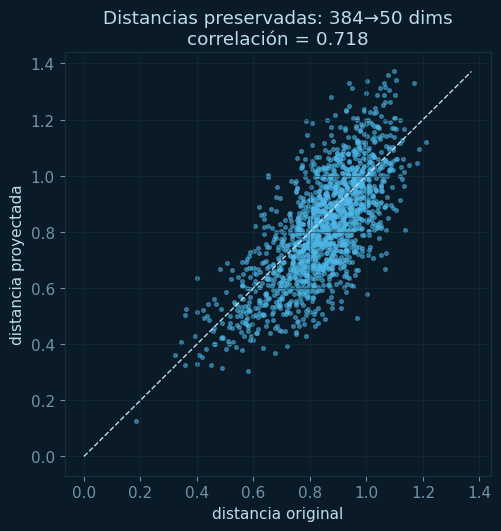

In [ ]:
display(intro("🎲", "Módulo F · Random projection (Johnson-Lindenstrauss)", [
 "<b>De qué se trata.</b> Un resultado tan contraintuitivo que parece imposible: podés comprimir de cientos de dimensiones a 50 multiplicando por una matriz <b>completamente al azar</b>, y las distancias entre frases se conservan casi perfectas.",
 "<b>Qué vas a ver.</b> Un scatter que compara la distancia entre frases en el espacio original (eje X) contra la misma distancia ya comprimida (eje Y). Vas a ver que casi todos los puntos caen sobre la diagonal: correlación cercana a 1.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> <code>E_proj = E · R</code> con R gaussiana. El lema de <b>Johnson-Lindenstrauss</b> dice que en alta dimensión una proyección aleatoria casi no distorsiona las distancias. A diferencia de la SVD, acá NO aprendés nada de los datos: sólo multiplicás por ruido.",
]))

k = 50
Rp = np.random.randn(E.shape[1], k) / np.sqrt(k)
E_proj = E @ Rp
d_orig = pdist(E, metric="cosine"); d_proj = pdist(E_proj, metric="cosine")
plt.figure(figsize=(5.5, 5.5))
plt.scatter(d_orig, d_proj, s=7, alpha=.5, color="#4fb8e8")
lims = [0, max(d_orig.max(), d_proj.max())]
plt.plot(lims, lims, "--", color="#bcdcec", lw=1)
plt.title(f"Distancias preservadas: {E.shape[1]}→{k} dims\ncorrelación = {np.corrcoef(d_orig, d_proj)[0,1]:.3f}")
plt.xlabel("distancia original"); plt.ylabel("distancia proyectada"); plt.show()

📝 **Lectura.** Cada punto compara la distancia entre dos frases en el espacio **original** contra esa misma distancia después de comprimir a 50 dimensiones con una matriz **completamente al azar**.

Que caigan casi todos sobre la diagonal (correlación ~1) parece imposible: ¿cómo puede una matriz random preservar la geometría? Y sin embargo lo hace — es el **lema de Johnson-Lindenstrauss**, uno de los resultados más contraintuitivos del álgebra lineal.

La diferencia con la SVD del módulo E: acá **no aprendés nada de los datos**, no calculás componentes, solo multiplicás por ruido — y aun así comprimís bien. Es la opción más barata y rápida cuando tenés millones de vectores y no querés pagar el costo de una SVD.

## 🌈 Módulo G · Morphing semántico

In [ ]:
display(intro("🌈", "Módulo G · Morphing semántico", [
 "<b>De qué se trata.</b> Probamos que el espacio de significados es un <b>continuo</b>, no un casillero de etiquetas sueltas. Tomamos dos frases muy distintas y nos movemos en línea recta de una a la otra, viendo qué frase real aparece en cada paso.",
 "<b>Qué vas a ver.</b> Una transición en 7 pasos, de &laquo;Messi levantó la copa&raquo; a &laquo;el asado del domingo&raquo;. En cada paso se imprime la frase del corpus más cercana a la mezcla. Vas a ver el significado mutar de a poco, pasando por frases-puente con sentido.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Una <b>combinación convexa</b>: <code>v = (1−α)·v₀ + α·v₁</code> con α de 0 a 1. Es la misma operación que usa la IA generativa cuando interpola entre dos conceptos.",
]))

i0 = texts.index("Messi levantó la copa tras la final contra Francia en 2022.")
i1 = texts.index("El asado del domingo reúne a la familia alrededor de la parrilla.")
v0, v1 = E[i0], E[i1]; En = normalizar(E)
print(f"De:  «{texts[i0]}»\nA:   «{texts[i1]}»\n")
for a in np.linspace(0, 1, 7):
    v = (1-a)*v0 + a*v1; v = v/np.linalg.norm(v)
    i = np.argmax(En @ v)
    print(f"  α={a:.2f} → [{topics[i]:9}] {texts[i]}")

De:  «Messi levantó la copa tras la final contra Francia en 2022.»
A:   «El asado del domingo reúne a la familia alrededor de la parrilla.»

  α=0.00 → [historia ] Messi levantó la copa tras la final contra Francia en 2022.
  α=0.17 → [historia ] Messi levantó la copa tras la final contra Francia en 2022.
  α=0.33 → [historia ] Messi levantó la copa tras la final contra Francia en 2022.
  α=0.50 → [historia ] Messi levantó la copa tras la final contra Francia en 2022.
  α=0.67 → [cultura  ] El asado del domingo reúne a la familia alrededor de la parrilla.
  α=0.83 → [cultura  ] El asado del domingo reúne a la familia alrededor de la parrilla.
  α=1.00 → [cultura  ] El asado del domingo reúne a la familia alrededor de la parrilla.


📝 **Lectura.** A medida que α avanza de 0 a 1, mezclamos los dos vectores en distintas proporciones y, en cada paso, mostramos la frase real más cercana a esa mezcla. Lo que ves es el significado **transformándose de a poco**: arranca en Messi/la copa, pasa por frases puente (de hinchada, de festejo, de familia) y termina en el asado.

La clave es que la transición es **continua y con sentido**: no hay saltos arbitrarios, hay un camino donde cada paso intermedio es semánticamente plausible.

Eso demuestra que el espacio de embeddings no es un casillero de etiquetas sueltas sino un **continuo** donde "moverse" en línea recta entre dos ideas atraviesa ideas relacionadas. Es la misma propiedad que explota la IA generativa cuando interpola entre conceptos.

## ⚪ Módulo H · Whitening

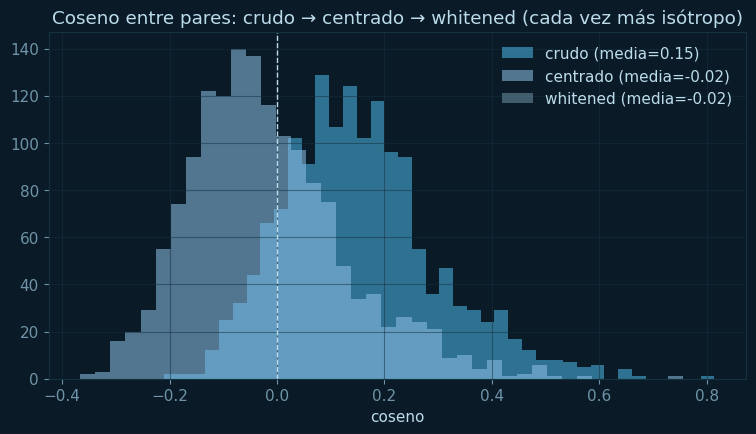

El whitening deja el coseno medio casi en 0: el cono desapareció del todo.


In [ ]:
display(intro("⚪", "Módulo H · Whitening (isotropización total)", [
 "<b>De qué se trata.</b> Centrar (sección 5) mató la DIRECCIÓN del cono, pero el cono también está <b>estirado</b>: unas direcciones tienen mucha más varianza que otras. El whitening lo aplana del todo, dejando la nube como una esfera perfecta.",
 "<b>Qué vas a ver.</b> Tres histogramas superpuestos del coseno entre pares: crudo, centrado y whitened. Cada paso acerca más la media a 0. El whitened queda prácticamente clavado en cero: el cono desapareció por completo.",
 "🧮 <b>Dónde mirar / álgebra lineal.</b> Usamos la matriz de <b>covarianza</b> y su raíz inversa: con la descomposición espectral <code>C = V Λ Vᵀ</code>, el blanqueador es <code>W = V Λ^(−1/2) Vᵀ</code>. Es el arreglo más completo del cono — pero también el más agresivo.",
]))

C = np.cov(Ec, rowvar=False)
lam, V = np.linalg.eigh(C); lam = np.clip(lam, 1e-8, None)
W = V @ np.diag(1.0/np.sqrt(lam)) @ V.T
E_white = Ec @ W
plt.figure()
plt.hist(pares(E),       bins=40, alpha=.55, label=f"crudo (media={pares(E).mean():.2f})",       color="#4fb8e8")
plt.hist(pares(Ec),      bins=40, alpha=.55, label=f"centrado (media={pares(Ec).mean():.2f})",    color="#8fc0e8")
plt.hist(pares(E_white), bins=40, alpha=.55, label=f"whitened (media={pares(E_white).mean():.2f})", color="#6f93a8")
plt.axvline(0, color="#bcdcec", ls="--", lw=1)
plt.title("Coseno entre pares: crudo → centrado → whitened (cada vez más isótropo)")
plt.xlabel("coseno"); plt.legend(); plt.show()
print("El whitening deja el coseno medio casi en 0: el cono desapareció del todo.")

📝 **Lectura.** Seguí los tres histogramas en orden: **crudo** (corrido a la derecha), **centrado** (más cerca del 0) y **whitened** (clavado en 0). Cada paso isotropiza más.

¿Qué hace el whitening que el centrado no? Centrar solo mueve el origen al medio del cono, pero el cono todavía está **estirado**: algunas direcciones tienen mucha más varianza que otras. El whitening usa la **covarianza y su raíz inversa** para "desinflar" las direcciones gordas y "engordar" las flacas, dejando la nube como una **esfera perfecta** (covarianza identidad).

Es el arreglo más completo del cono — pero ojo, también el más agresivo: a veces esas direcciones de mucha varianza contienen información útil, así que aplanar todo puede borrar señal. Por eso en la práctica el centrado simple suele ser suficiente, y el whitening se reserva para cuando lo medís y conviene.

## 🏁 Cierre

| Concepto | Álgebra lineal | Para qué sirve |
|---|---|---|
| Embedding | vector / matriz `E` | representar significado |
| Parecido | matriz de Gram `Ê·Êᵀ` | buscar, comparar |
| Cono | dirección media `μ` | entender por qué "todo se parece un poco" |
| Centrar | resta `E−μ` | mejora el coseno y el clustering por coseno |
| PCA/SVD | `UΣVᵀ` | comprimir, dimensión efectiva, interpretar ejes |
| Analogías | suma/resta de vectores | relaciones semánticas |
| Ejes de concepto | producto punto | rankear por un atributo |
| Rotación | matriz ortogonal `Q` | el coseno solo ve ángulos |
| Compresión | rango bajo (Eckart-Young) | menos memoria, casi sin pérdida |
| Random projection | `E·R` (Johnson-Lindenstrauss) | comprimir preservando distancias |
| Morphing | combinación convexa | transición de significado |
| Whitening | raíz inversa de la covarianza | isotropización total |

